# Classification: Did they shop or not? </br> Using Online Shoppers Purchase Intention Dataset to predict binary shopping behavior.

**Team Members**:</br>

*Dominique Chen*

*Ja Kaewwetchawong*

*Nizel Abalos*

*Paridhi Bansa*



## Summary:
We trained a Random Forest classifier to predict whether an online shopping session would end in a purchase. The model achieved an accuracy of 0.89 and a ROC–AUC of 0.91, showing good overall ability to distinguish between purchase and non-purchase sessions. However, because the data were imbalanced, performance differed by class: the model identified non-purchasers very well, but was less effective at detecting actual buyers, with a recall of 0.51 and an F1-score of 0.60 for the purchase class. Overall, the results suggest that the classifier is useful for separating the two groups, but still misses a substantial number of true purchase sessions.

## Introduction:
The increased use of mobile technology and developments in technological infrastructure in the past decade has significantly disrupted consumers’ behaviour, with many preferring to shop using online platforms. As a result, e-commerce became one of the fastest growing markets in the world with an estimated market size of $25.93 trillion USD in 2023 and is projected to reach 83.26 trillion USD by 2030, a growth of 18.9% (Grand View Research, 2026). With its large market size, new entrepreneurs are looking to break into the ecommerce scene to gain a hold of its shares. Most of the research into online consumer behaviours focus on website features and its effect on the psychological motivation behind purchasing behaviours. For instance, Jiradilok et al. (2014) found that consumers prioritized assurance, pricing, and website quality/security when making online purchases . However, there is a lack of research into customers' website usage, such as the time they spent on a page or the categories they browsed. For this reason, we are interested in investigating the following question:

>**What is the probability that an online shopper completes a purchase based on their browsing behaviour and which feature(s) contributes the most to the outcome?**

**Dataset:**
We will be using a 2018 [Online Shoppers Purchasing Intention](https://archive-beta.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) public dataset containing a total of 12,330 rows and 18 features.

**Numerical**:  
`Administrative`: Number of administrative pages visited (e.g. login pages)  
`Administrative_Duration`: Time spent on administrative pages in unit of seconds.  
`Informational`: Number of informational pages visited (e.g. product content page)  
`Informational_Duration`: Time spend on informational pages in unit of seconds.  
`ProductRelated`: Number of product-related pages visited  
`ProductRelated_Duration:`: Time spent on product related pages  
`BounceRates:` Range 0 to 1, the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session.  
`ExitRate`: Range 0 to 1, the percentage that a page was the last one viewed in a session.  
`PageValues`: Average value of a page before purchase.  
`Special Day`:  The closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day)  

**Categorical**:   
`Month`: Month of the session.  
`OperatingSystems`: 8 categories, ID of operating system.  
`Browser`: 13 categories, browser used by the visitor.  
`Region`: 9 categories, Geographic region from which the session has been started by the visitor.  
`TrafficType:` 20 categories, Traffic source by which the visitor has arrived at the Web site (e.g., banner, SMS, direct)  
`VisitorType`: 3 categories, for new, returning and other visitors.  
`Weekend`: boolean value indicating whether it is weekend.  
`Revenue`: boolean value of whether the visit is finalized with a transaction


## Methods & Results

1. **Exploratory Data Analysis** \
Here we are examining the dataset for missing values, checking for class imbalances, and plotting each features to see its distribution. This provides an idea of the kind of dataset we are working with and the suitability of each predictive model for the classification problem. 
3. **Splitting the Dataset** \
The data is splitted into train and test set. The training set will be used to train the model whereas the test set will be used to assess the accuracy and performance of our model's prediction.
5. **Purchase Prediction using Random Forest Classifier** \
We trained a tree based ensemble model, random forest classifier, on the training data and using it to predict whether the customer has made a purchase. The model is then assessed using F1 score to account for class imbalance. 
7. **Feature Importances** \
Feature importance and SHAP summary plots are used to better understand the influence of each features on the model's prediction. 

### Data loading and checking missing values

In [1]:
# Code loading data from original source
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)
df.to_csv("data/data.csv", index=False)

In [2]:
#Checking for missing entry
df.shape

print("Table1: Data Column Names, Value Counts and Data Types")
df.info()
df.head(6)

Table1: Data Column Names, Value Counts and Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region               

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False


> No missing values were detected across variables

In [3]:
# Convert boolean variables
# Make a copy of the raw data to work with
online=df.copy()
online['Weekend'] = online['Weekend'].astype(int)
online['Revenue'] = online['Revenue'].astype(int)
# One-hot Encoding on categorical variables
online = pd.get_dummies(online, columns=['Month', 'VisitorType'], drop_first=True)
#Check for class balance
online['Revenue'].value_counts(normalize=True)

Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64

> The target variable (Revenue) is imbalanced, with a substantially larger proportion of sessions not resulting in a purchase.

In [4]:
#Check for OHE
online['Weekend']

0        0
1        0
2        0
3        0
4        1
        ..
12325    1
12326    1
12327    1
12328    0
12329    1
Name: Weekend, Length: 12330, dtype: int64

### EDA figures

In [5]:
import seaborn as sns

Figure 1.Histogram for All Feature Values and Counts


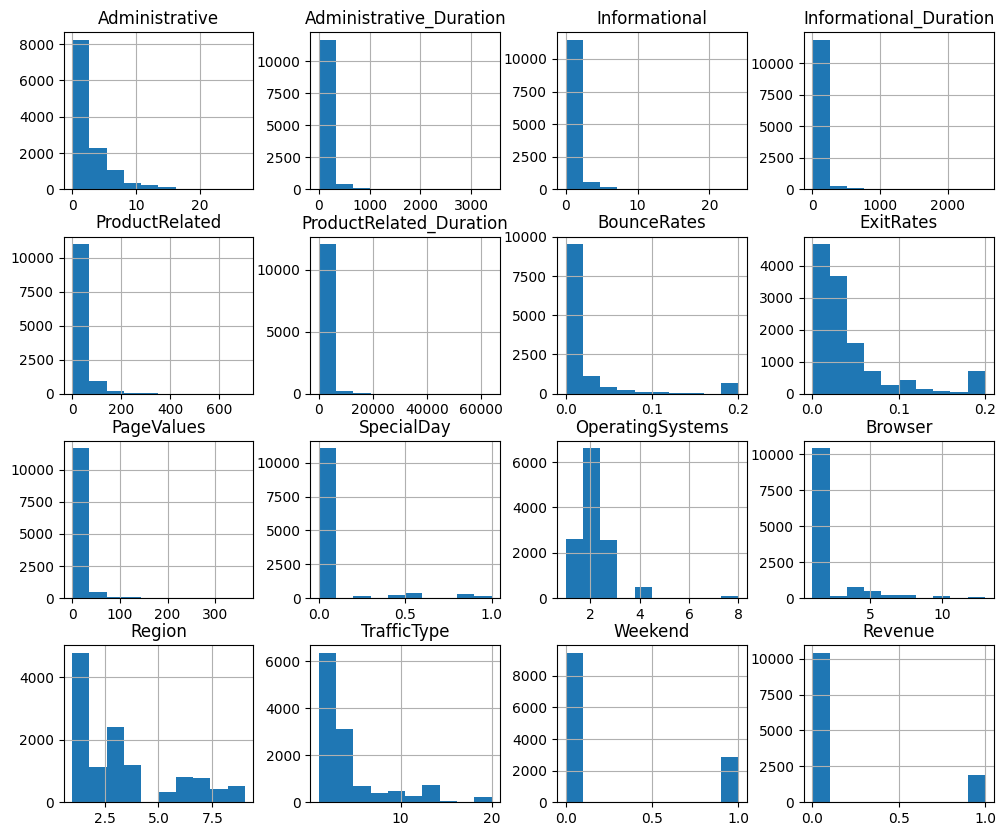

In [6]:
online.hist(figsize=(12,10))
print("Figure 1.Histogram for All Feature Values and Counts")

> The histograms show that most numerical variables (e.g., `Administrative`, `Informational`, `ProductRelated`) are highly right-skewed, with a large number of sessions having low values. This suggests that most users interact minimally with the website, and only a minority exhibit intensive browsing behavior. We will consider log transformations (or use tree-based classifiers) so that a few extreme browsing sessions do not dominate the learning signal when predicting Revenue.
>
> We spot that many features are 'zero-heavy', thus we need a model that is robust to the zero-inflation.
> 
> Also because `Revenue` is imbalanced, we will use evaluation metrics beyond accuracy (e.g., F1) to ensure the classifier meaningfully identifies purchasing sessions.

### Training a Random Forest Classifier

In [7]:
from sklearn.model_selection import train_test_split
#Train-test split
X = online.drop("Revenue", axis=1)
y = online["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [8]:
#Train a random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"  # VERY important
)

rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
#Evaluate using f1 metrics and AUC
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2084
           1       0.73      0.51      0.60       382

    accuracy                           0.89      2466
   macro avg       0.82      0.74      0.77      2466
weighted avg       0.89      0.89      0.89      2466

ROC-AUC: 0.9163848720241984


> 0 means no purchase, and 1 means purchase.
>
> Accuracy is 0.89, but it is inflated due to class imbalance discovered in EDA. We need to analyze the results on a class-by-class bases.
>
> For class 0, precision, recall, and f1 score are all above 0.9, suggesting the model performs well in predicting non-purchase scenarios.
>
> For class 1, the metrics are much lower. A recall of 0.5 means only 51% of actual buyers are correctly classified, which could be due to lack of actual buyer data in the dataset. The f1 score of 0.6 is moderate, but not strong.
>
> To sum up, a ROC-AUC of 0.91 means the model has high discriminative ability and can separate buyers and non-buyers well, but suffers from low recall for the buyer class.

### Feature Importance Plot

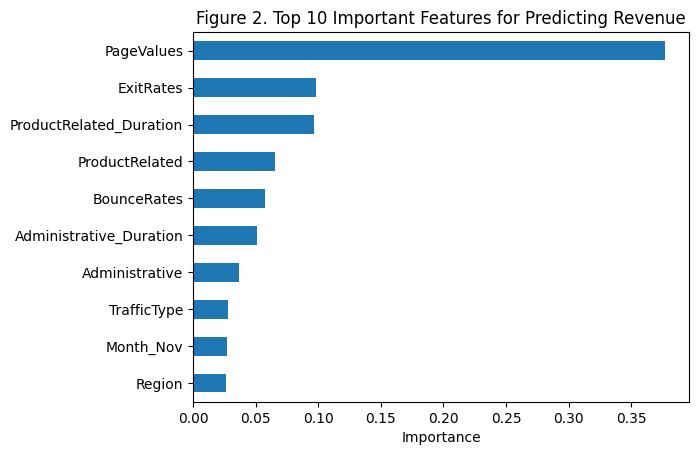

In [10]:
import matplotlib.pyplot as plt
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
importances.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Figure 2. Top 10 Important Features for Predicting Revenue")
plt.xlabel("Importance")
plt.show()


This plot ranks variables based on how much they contribute to model decisions. 

1. **PageValues:** This feature has the largest impact on predictions. Higher PageValues strongly increase the likelihood of purchase, indicating that visitors that interact with high-value pages are more likely to convert.

2. **ExitRates:** Higher exit rates decrease the probability of purchase, suggesting that users leaving pages frequently are less engaged.

3. **ProductRelated_Duration:** More time spent on product pages increases the chance of purchase, reflecting deeper product evaluation.

4. **ProductRelated:** Viewing more product pages is associated with a higher chance of purchase.

5. **BounceRates:** Higher bounce rates reduce the likelihood of conversion, as users leaving quickly are unlikely to buy.

Other features such as `TrafficType`, `Month_Nov`, and `Region` have a smaller impact on the model. Overall the features involving customer engagement are the strongest predictor of whether a customer will purchase or not.

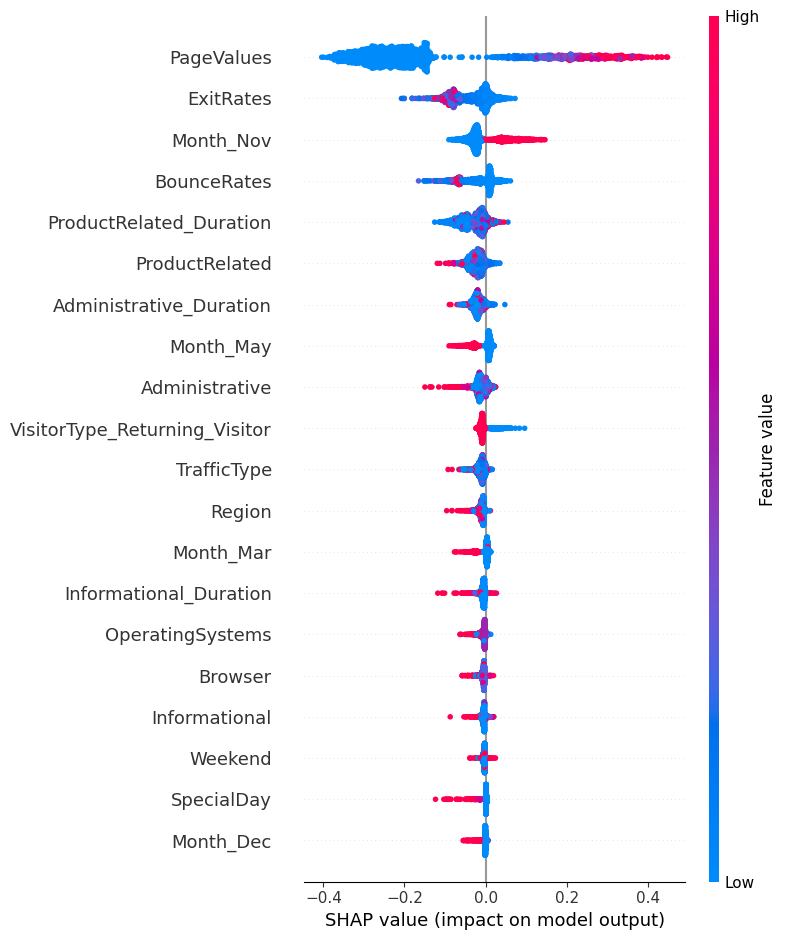

Figure 3. SHAP Summary Plot for Purchase Prediction (Random Forest)


In [11]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap_values_class1 = shap_values[:,:,1]
shap.summary_plot(shap_values_class1, X_test)
print("Figure 3. SHAP Summary Plot for Purchase Prediction (Random Forest)")

The SHAP plot above shows how feature values influence predictions:
* High `PageValues` strongly push predictions towards purchase, and it indicates that users viewing high-value pages are very likely to convert
* High `ExitRates` relate to negative SHAP values, indicating that when users frequently exit pages, the model predicts lower purchase probability.
* There is a seasonality effect for `Month_Nov`, where the month of November tends to push predictions towards purchase. This is likely due to Black Friday or holiday shopping behaviour, making customers more likely to purchase.
* High `BouceRates` push predictions towards no purchase, indicating that users who leave quickly are unlikely to buy.
* `ProductRelated_Duration` shows that a longer time spend on product pages indicates a higher likelihood of purchasing.
* `VisitorType_Returning_Visitor` shows that returning visitors are more likely to purchase and are more likely to convert than new visitors.

From the results, we can see that engagement is the strongest predicture where features related to time spend and pages viewed dominate the model and are highly related to whether a customer purchases or not.

## Discussion

Overall, we found that browsing behaviour can be used to predict whether an online shopper will complete a purchase with reasonably strong performance. Our Random Forest classifier achieved an overall accuracy of 0.89 and a ROC-AUC of 0.91, which suggests that the model was good at distinguishing between purchasing and non-purchasing sessions. However, because the data was imbalanced, the more important result was the class-specific performance. The model performed very well at identifying non-purchasing sessions, but it was less effective at identifying actual buyers, with a recall of 0.51 and an F1 score of 0.60 for the purchase class. We also found that engagement-related features were the most important predictors of shopping behaviour. In particular, PageValues, ExitRates, ProductRelated_Duration, ProductRelated, and BounceRates had the strongest influence on the model’s predictions. The SHAP analysis also suggested that longer time spent on product-related pages, being a returning visitor, and shopping in November were associated with a higher likelihood of purchase.  

This was mostly what we expected to find. We expected browsing engagement to be strongly related to purchase behaviour, since users who spend more time on valuable or product-related pages are likely showing stronger interest in buying something. Similarly, it makes sense that high bounce rates and exit rates were associated with not purchasing, because these behaviours may suggest low interest, distraction, or a poor browsing experience. One result that was slightly less desirable than expected was the lower recall for the buyer class. Although the model separated the two classes well overall, it still missed many actual purchasers, which shows that predicting buyers is more difficult than predicting non-buyers in this dataset.  

These findings could have useful practical impacts for e-commerce businesses. If browsing behaviour can help predict purchase intention, companies could use this information to improve website design, personalize recommendations, identify high-intent users, or target promotions more effectively. For example, if a business can detect that a user is showing strong purchase intent based on product-page engagement and page value, it may be able to intervene with discounts, reminders, or better recommendations at the right time. At the same time, the model’s lower recall for buyers means that businesses should be cautious about relying on it too heavily in real-world settings, since many potential customers may still be missed.  

This project also leads to several future questions. One important question is whether other models, such as gradient boosting or XGBoost, could improve prediction performance for the buyer class. Another is whether methods addressing class imbalance, such as resampling or threshold tuning, could increase recall without hurting overall performance too much. Handling imbalanced datasets is a well-known challenge in machine learning because standard classifiers tend to be biased toward the majority class, often leading to poor detection of minority-class instances (He & Garcia, 2009). It would also be interesting to examine whether these behavioural patterns stay consistent across different visitor types, traffic sources, or times of year. Finally, future research could explore whether adding more detailed user-level or session-level information would make purchase prediction even more accurate.

## Citation

Grand View Research. (2026, March 7). E-commerce market (2024–2030). https://www.grandviewresearch.com/industry-analysis/e-commerce-market

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

Jiradilok, T., Malisuwan, S., Madan, N., & Sivaraks, J. (2014). The impact of customer satisfaction on online purchasing: A case study analysis in Thailand. Journal of Economics, Business and Management, 2(1), 5–11. https://doi.org/10.7763/JOEBM.2014.V2.89

Sakar, C. O., Polat, S. O., Katircioglu, M., & Kastro, Y. (2019). Real-time prediction of online shoppers’ purchasing intention using multilayer perceptron and LSTM recurrent neural networks. Neural Computing and Applications, 31, 6893–6908. https://doi.org/10.1007/s00521-018-3523-0